In [4]:
import keras
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, Embedding, SimpleRNN, LSTM, GRU, Input
from keras.preprocessing.sequence import pad_sequences
from keras.optimizers import Adam


vocabulary_size = 10000
(X_train, y_train), (X_test, y_test) = keras.datasets.imdb.load_data(num_words=vocabulary_size)

max_length = 150

X_train = pad_sequences(X_train, maxlen=max_length, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=max_length, padding='post', truncating='post')

embed_size = 128



model_rnn = Sequential([
    Input(shape=(None,)),
    Embedding(vocabulary_size, embed_size),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])


model_lstm = Sequential([
    Input(shape=(None,)),
    Embedding(vocabulary_size, embed_size),
    LSTM(64),
    Dense(1, activation='sigmoid')
])


model_gru = Sequential([
    Input(shape=(None,)),
    Embedding(vocabulary_size, embed_size),
    GRU(64),
    Dense(1, activation='sigmoid')
])

In [5]:

model_rnn.compile(loss="binary_crossentropy", optimizer=Adam(0.001), metrics=["accuracy"])
model_lstm.compile(loss="binary_crossentropy", optimizer=Adam(0.001), metrics=["accuracy"])
model_gru.compile(loss="binary_crossentropy", optimizer=Adam(0.001), metrics=["accuracy"])

epochs = 5


history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)

history_gru = model_gru.fit(
    X_train, y_train,
    epochs=epochs,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - accuracy: 0.5061 - loss: 0.6965 - val_accuracy: 0.4994 - val_loss: 0.7024
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.6534 - loss: 0.6039 - val_accuracy: 0.4940 - val_loss: 0.7798
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.7876 - loss: 0.3803 - val_accuracy: 0.5172 - val_loss: 0.9467
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.8529 - loss: 0.2497 - val_accuracy: 0.5336 - val_loss: 1.1774
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.8801 - loss: 0.2054 - val_accuracy: 0.5112 - val_loss: 1.3333
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 115ms/step - accuracy: 0.6015 - loss: 0.6542 - val_accuracy: 0.5044 - val_loss: 0.6918
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.6836 - loss: 0.5829 - val_accuracy: 0.8070 - val_loss: 0.4763
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 116ms/step - accuracy: 0.8593 - loss: 0.3408 - val_a


=== Test Results ===
Model        Accuracy  
Simple RNN   51.20%
LSTM         82.50%
GRU          82.16%


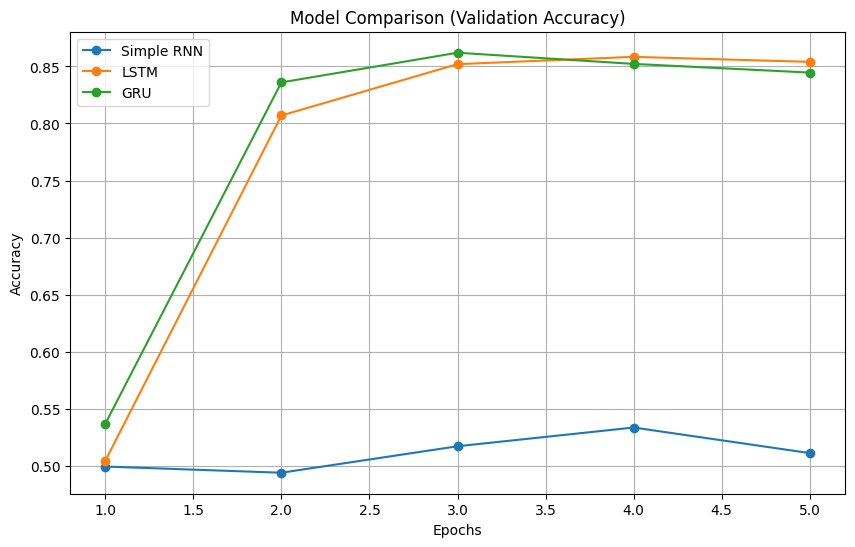

In [6]:
models = {
    "Simple RNN": model_rnn,
    "LSTM": model_lstm,
    "GRU": model_gru
}

histories = {
    "Simple RNN": history_rnn,
    "LSTM": history_lstm,
    "GRU": history_gru
}


print("\n=== Test Results ===")
print(f"{'Model':<12} {'Accuracy':<10}")

for name, model in models.items():
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{name:<12} {acc*100:.2f}%")


plt.figure(figsize=(10,6))

for name, history in histories.items():
    val_acc = history.history["val_accuracy"]
    epochs_range = range(1, len(val_acc) + 1)
    plt.plot(epochs_range, val_acc, marker='o', label=name)

plt.title("Model Comparison (Validation Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.show()